In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
print(sys.executable)

/Users/vimalranchhod/anaconda3/envs/churn-env/bin/python3.10


In [55]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [56]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"].str.strip().replace("",None),errors="coerce")
df['Churn'] = np.where(df['Churn'] =='Yes',1,0)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [58]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


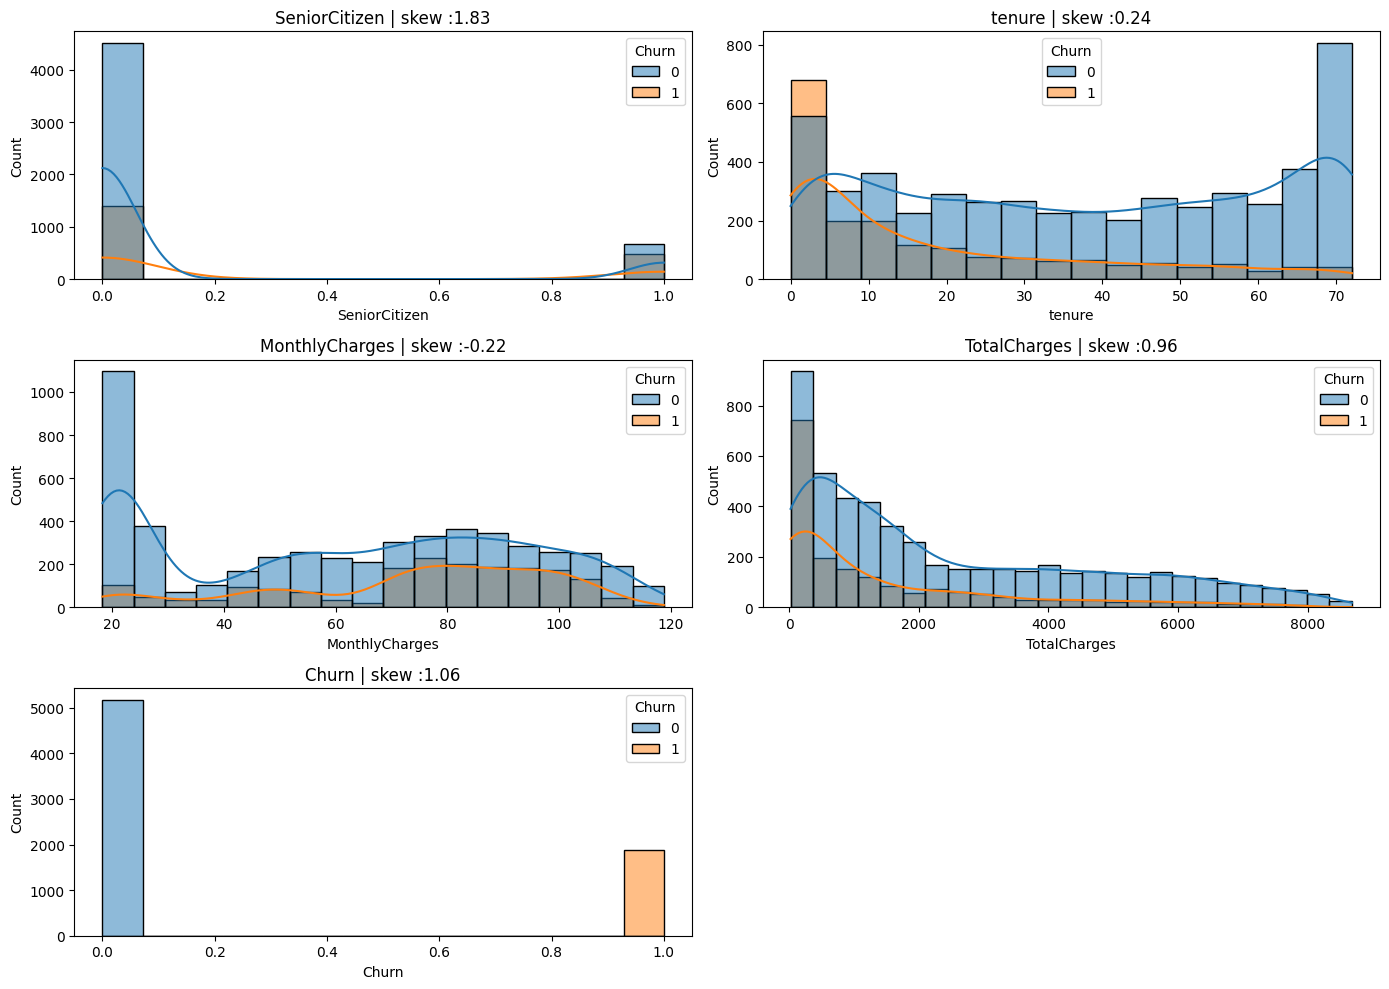

In [68]:
cols = df.select_dtypes(include="number").columns

n = len(cols)

fig,axes = plt.subplots(nrows = (n+1)//2,ncols = 2,figsize = (14,n*2))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(x= df[col],kde=True,ax=axes[i],hue = df['Churn'])
    axes[i].set_title(f"{col} | skew :{df[col].skew():.2f}")

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

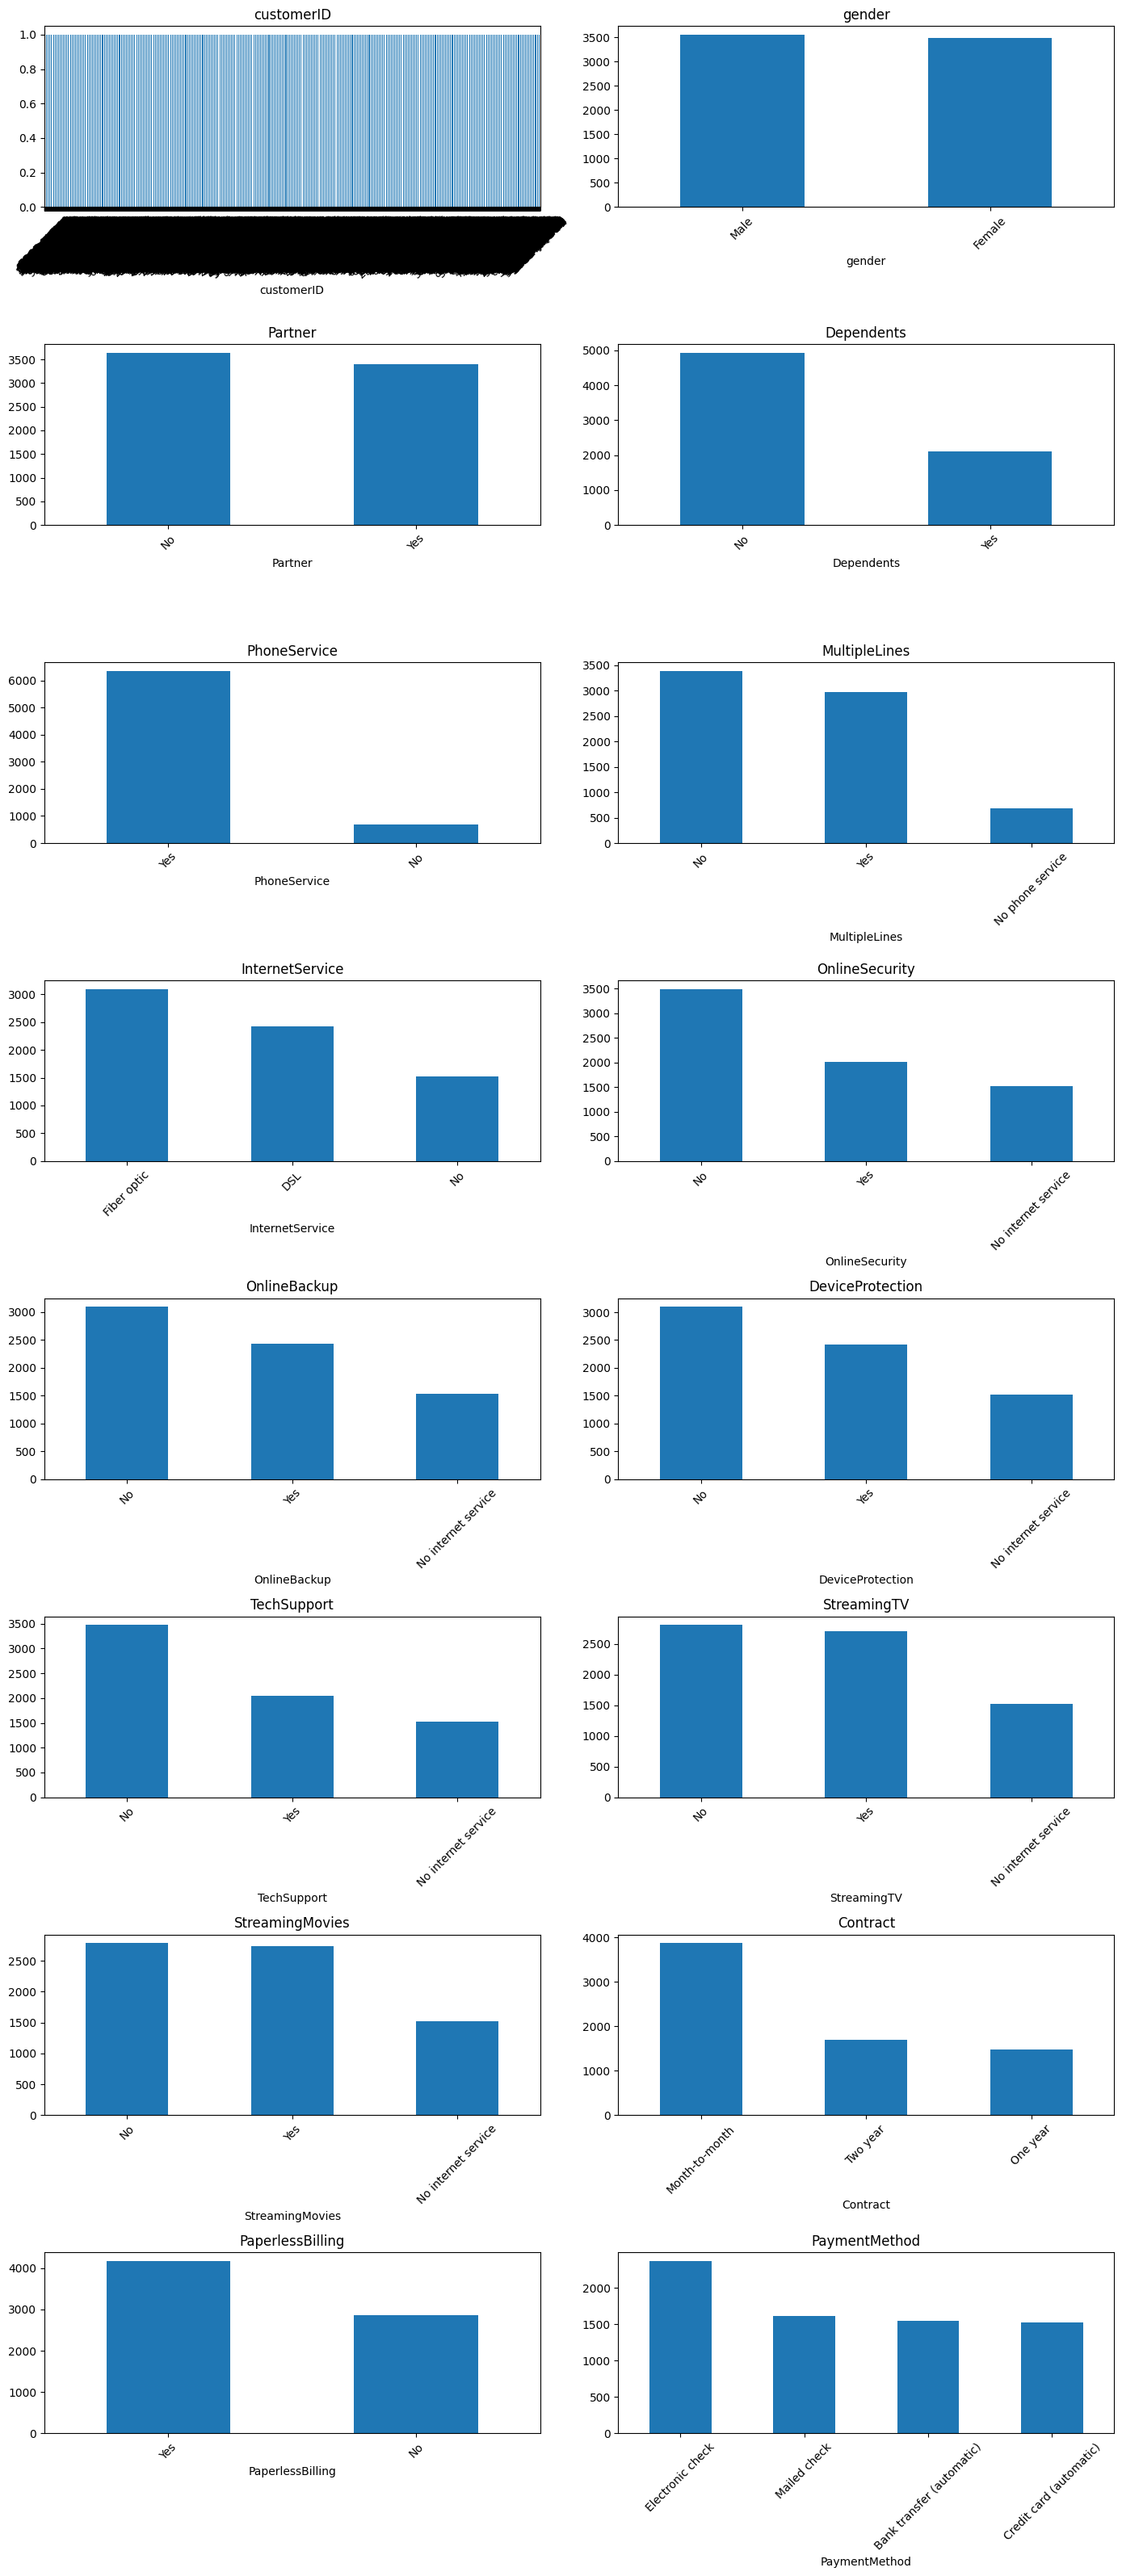

In [60]:
cols = df.select_dtypes(include = "object").columns
n=len(cols)

fix,axes = plt.subplots(nrows = (n+1)//2,ncols = 2,figsize = (14,n*2))
axes = axes.flatten()

for i,col in enumerate(cols):
    df[col].value_counts().plot(kind = "bar",ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x",rotation=45)

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
                       

In [61]:
cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

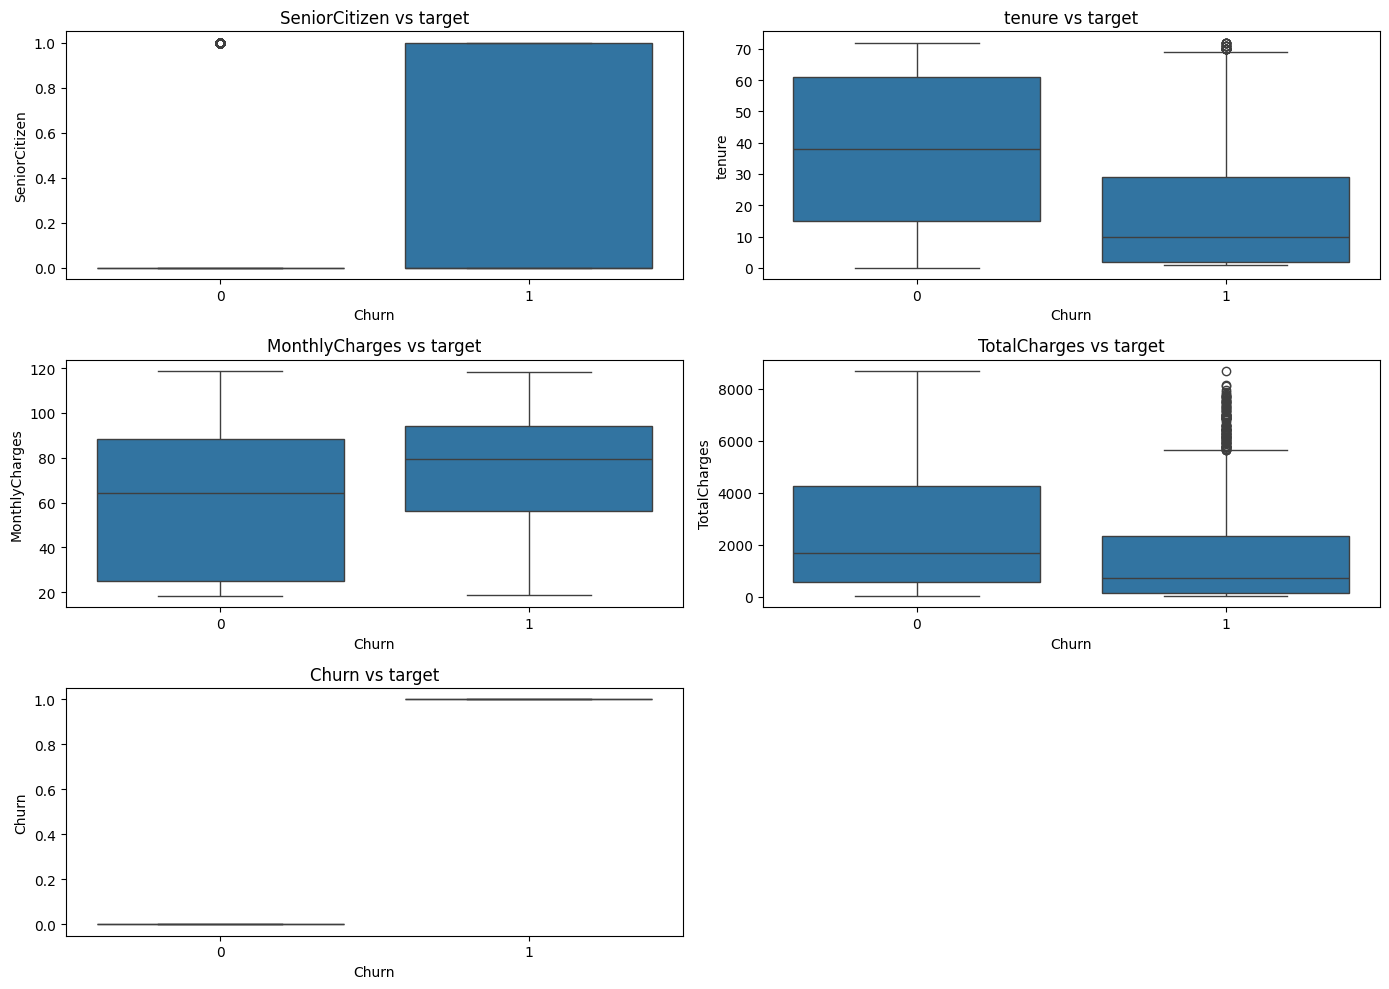

In [62]:
cols = df.select_dtypes(include = "number").columns
n = len(cols)

fig,axes =  plt.subplots(nrows = (n+1)//2, ncols = 2,figsize = (14,n*2))
axes = axes.flatten()

for i,col in enumerate(cols):
    sns.boxplot(x="Churn",y=col,data=df,ax=axes[i])
    axes[i].set_title(f"{col} vs target")

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [64]:
df['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64